# Hierarchy in the US faculty hiring network

Graph Algorithms — final project
Prof. Stefano Guarino — Master in Data Analytics, Roma Tre University
Student: Simone Felicioni

---

The question this project answers: is the US academic job market organised as a hierarchy,
and can we show it using the network alone, without ever looking at an external university ranking?

## Contents

1. [The data](#1-the-data)
2. [A check before building anything: who hires, and who only supplies?](#2-a-check-before-building-anything-who-hires-and-who-only-supplies)
3. [Self-loops: universities hiring their own graduates](#3-self-loops-universities-hiring-their-own-graduates)
4. [Building the two graphs](#4-building-the-two-graphs)
5. [Taxonomy and basic topological properties](#5-taxonomy-and-basic-topological-properties)
6. [Connected components, and a trap](#6-connected-components-and-a-trap)
7. [Degree distributions](#7-degree-distributions)
8. [Is any of this a power law?](#8-is-any-of-this-a-power-law)
9. [Centrality: which universities are important, and in what sense?](#9-centrality-which-universities-are-important-and-in-what-sense)
10. [Transitivity](#10-transitivity)
11. [Community structure](#11-community-structure)
12. [Assortativity](#12-assortativity)
13. [Null models: what is actually surprising here?](#13-null-models-what-is-actually-surprising-here)
14. [Where the hierarchy actually lives](#14-where-the-hierarchy-actually-lives)
15. [Drawing the network](#15-drawing-the-network)
16. [Saving the results](#16-saving-the-results)

## 1. The data

`faculty_hiring_us` (network `academia`) from
[networks.skewed.de](https://networks.skewed.de/net/faculty_hiring_us), published with
Wapman, Zhang, Clauset & Larremore, *Nature* 610, 120–127 (2022).

- a node is a university
- an edge `i -> j` means: somebody got their PhD at `i` and was hired as faculty at `j`
- the weight `total` is how many people made that move, 2011–2020
- each edge also splits that count into `men` and `women`
- each node carries `non_attrition` and `attrition`: faculty who stayed, faculty who left

**Implementation note.** The CSV headers are written as a comment line (`# source, target, ...`),
so pandas reads the first column as `"# source"` and gives all the others a leading space. Every
lookup by column name would fail. `clean()` repairs them.

In [1]:
import pandas as pd
import igraph


def clean(df):
    """Repair the column names: drop the leading '#' and any stray spaces."""
    new_names = []
    for c in df.columns:
        c = c.strip()
        c = c.lstrip("# ")
        new_names.append(c)
    df.columns = new_names
    return df


nodes = clean(pd.read_csv("data/nodes.csv"))
edges = clean(pd.read_csv("data/edges.csv"))

print("nodes:", nodes.shape, list(nodes.columns))
print("edges:", edges.shape, list(edges.columns))
print(f"total hires: {edges['total'].sum():,}"
      f"  (men {edges['men'].sum():,}, women {edges['women'].sum():,})")

nodes: (3284, 6) ['index', 'id', 'name', 'non_attrition', 'attrition', '_pos']
edges: (61936, 5) ['source', 'target', 'total', 'men', 'women']
total hires: 274,474  (men 152,042, women 81,846)


## 2. A check before building anything: who hires, and who only supplies?

Before turning this into a graph, one basic question: **which universities appear as the source of
an edge, and which appear as the target?**

In an ordinary hiring network those two sets would be roughly the same, since universities both train
people and employ them. Here they are not.

In [2]:
# a "set" keeps each value once, so len() counts distinct universities
hirers = set(edges["target"])

print("universities in the node file :", len(nodes))
print("universities that PLACE PhDs  :", edges["source"].nunique())
print("universities that HIRE faculty:", len(hirers))

universities in the node file : 3284
universities that PLACE PhDs  : 3282
universities that HIRE faculty: 368


Only 368 of 3,284 ever hire. To understand why, we look at the biggest universities that
never appear as a target.

In [3]:
# how many people each university placed in total
placed = edges.groupby("source")["total"].sum()

# ~ means NOT: keep the nodes that never appear as a target
never_hire = nodes[~nodes["index"].isin(hirers)].copy()
never_hire["placed"] = never_hire["index"].map(placed)

print(never_hire.nlargest(10, "placed")[["name", "placed"]].to_string(index=False))

                             name  placed
            University of Toronto    1238
          University of Cambridge    1080
             University of Oxford    1027
 City University of New York, The     729
             University of London     629
   University of British Columbia     616
                Mcgill University     583
            University of Alberta     396
Lomonosov Moscow State University     318
                       ETH Zurich     301


**Toronto, Cambridge, Oxford, London, British Columbia, McGill, Alberta, Moscow, ETH Zurich.**
They are not American.

That is the whole explanation. Wapman et al. collected the faculty rosters of **368 US
institutions**. Those professors earned their PhDs all over the world, so a foreign university
appears as a source of people but never as a hirer, because nobody collected its roster.

So the file superimposes two different objects, and we have to separate them:

- a supply network: all 3,284 nodes, answering who supplies US academia with professors;
- a market network: only the 368 institutions whose rosters are observed, answering *how
  professors move between US universities*. This is the only part where both ends of an edge are
  measured the same way, so it is where all structural analysis belongs.

Reading the whole file as one homogeneous network produces a spectacular but false result, which
we document in Section 4.

In [4]:
internal = edges[edges["source"].isin(hirers) & edges["target"].isin(hirers)]
external = edges[~edges["source"].isin(hirers)]

print(f"hires with both ends observed : {internal['total'].sum():,} "
      f"({100 * internal['total'].sum() / edges['total'].sum():.1f}%)")
print(f"hires supplied from outside   : {external['total'].sum():,} "
      f"({100 * external['total'].sum() / edges['total'].sum():.1f}%)")

hires with both ends observed : 238,986 (87.1%)
hires supplied from outside   : 35,488 (12.9%)


## 3. Self-loops: universities hiring their own graduates

An edge can start and end at the same university: somebody earned their PhD there and was then
hired there as faculty. In the literature this is called academic inbreeding.

Before deciding what to do with these edges, we need to know how many there are.

In [5]:
# same filtering idea as before: keep the rows where source and target are the same university
self_loops = edges[edges["source"] == edges["target"]]

print("self-loop edges :", len(self_loops))
print(f"people involved : {self_loops['total'].sum():,}")
print(f"share of all hires: {100 * self_loops['total'].sum() / edges['total'].sum():.1f}%")

self-loop edges : 358
people involved : 26,720
share of all hires: 9.7%


A self-loop inflates a university's in- and out-numbers with people who never moved anywhere, and
it can never help connect that university to a different one. So we **remove self-loops from the
graphs but keep their counts in a separate variable**, and come back to academic inbreeding
later as a finding in its own right.

## 4. Building the two graphs

Now we turn the tables into igraph objects, the same `Graph` object as the toy network, just
bigger.

- **`GS`, the supply network**: all 3,284 universities. Answers who supplies US academia.
- **`G`, the market network**: only the 368 institutions whose faculty rosters were observed.
  Answers how professors move between US universities. This is where every structural
  measurement belongs, because it is the only part of the data where both ends of an edge are
  measured the same way.

In [6]:
# keep the self-hire counts before we throw the edges away
self_hires = self_loops.set_index("source")["total"]

# Graph.DataFrame builds a graph from two tables: one of edges, one of vertices.
# The first two columns of the edge table are read as (source, target); the rest become
# edge attributes. The first column of the vertex table is the id; the rest become
# vertex attributes.
GS = igraph.Graph.DataFrame(
    edges[["source", "target", "total", "men", "women"]],
    directed=True,
    vertices=nodes[["index", "name", "non_attrition", "attrition"]],
)

# drop every edge whose two endpoints are the same vertex
GS.delete_edges([e.index for e in GS.es if e.source == e.target])

# induced_subgraph keeps only the vertices we list, plus the edges that run between them
G = GS.induced_subgraph(sorted(hirers))

print("supply network:", GS.summary())
print("market network:", G.summary())

supply network: IGRAPH DN-- 3284 61578 -- 
+ attr: attrition (v), index (v), name (v), non_attrition (v), men (e), total (e), women (e)
market network: IGRAPH DN-- 368 36870 -- 
+ attr: attrition (v), index (v), name (v), non_attrition (v), men (e), total (e), women (e)


## 5. Taxonomy and basic topological properties

Where the project brief asks us to *"classify the network based on the discussed taxonomy"* and
"summarize the basic topological properties".

The classification:

- **Directed**, and the direction carries the whole meaning: `i -> j` ("i trained someone that j
  hired") is a completely different statement from `j -> i`.
- **Weighted**, and the weight is a headcount, a real quantity that can be summed, not a
  similarity score.
- **Simple** after preprocessing: one row per ordered pair, and we removed the self-loops.
- **Not bipartite**, and static: the whole decade is aggregated, no per-edge timestamp.

Now the numbers. `reciprocity` is the share of edges that have a matching edge in the opposite
direction: how often two universities exchange people both ways.

In [7]:
import pandas as pd

rows = []
for g, label in [(GS, "supply (3,284)"), (G, "market (368)")]:
    n, m = g.vcount(), g.ecount()
    rows.append({
        "network": label,
        "nodes": n,
        "edges": m,
        "density": m / (n * (n - 1)),      # edges that exist / edges that could exist
        "mean degree": m / n,
        "reciprocity": g.reciprocity(),
        "diameter": g.diameter(),
        "avg path length": g.average_path_length(),
    })

basic = pd.DataFrame(rows).set_index("network")
print(basic.to_string(float_format=lambda v: f"{v:.4f}"))

                nodes  edges  density  mean degree  reciprocity  diameter  avg path length
network                                                                                   
supply (3,284)   3284  61578   0.0057      18.7509       0.3174         7           2.2691
market (368)      368  36870   0.2730     100.1902       0.5301         6           1.8184


## 6. Connected components, and a trap

Where the brief asks us to *"identify the connected components and determine their size, establish
the existence of a giant component"*.

Two versions of the question, and on a directed graph they give very different answers:

- **weakly** connected: ignore the arrows, just ask whether a route exists at all
- **strongly** connected: respect the arrows, so every university in the group must be able to reach
  every other one following the direction of the edges

We run both, on both networks.

In [8]:
for g, label in [(GS, "supply"), (G, "market")]:
    weak = g.connected_components(mode="weak")
    strong = g.connected_components(mode="strong")
    print(f"{label:7s}  weak: {len(weak):5,} components (largest {max(weak.sizes()):5,})"
          f"   strong: {len(strong):5,} components (largest {max(strong.sizes()):5,}ìì)")

# how many of the supply network's strong components are a single university?
sizes = GS.connected_components(mode="strong").sizes()
alone = sum(1 for s in sizes if s == 1)
print(f"\nsupply network: {alone:,} of its {len(sizes):,} strong components are a single node")

supply   weak:     1 components (largest 3,284)   strong: 2,922 components (largest   363ìì)
market   weak:     1 components (largest   368)   strong:     6 components (largest   363ìì)

supply network: 2,921 of its 2,922 strong components are a single node


### The component size distribution

The brief also asks us to plot the component size distribution. On this network the plot is worth
having for a specific reason: it makes the artefact visible. The supply network has one bar at size
363 and 2,921 bars at size 1, and no bar anywhere in between. A distribution with that shape is not
what a hierarchy looks like; it is what a one-sided sample looks like.

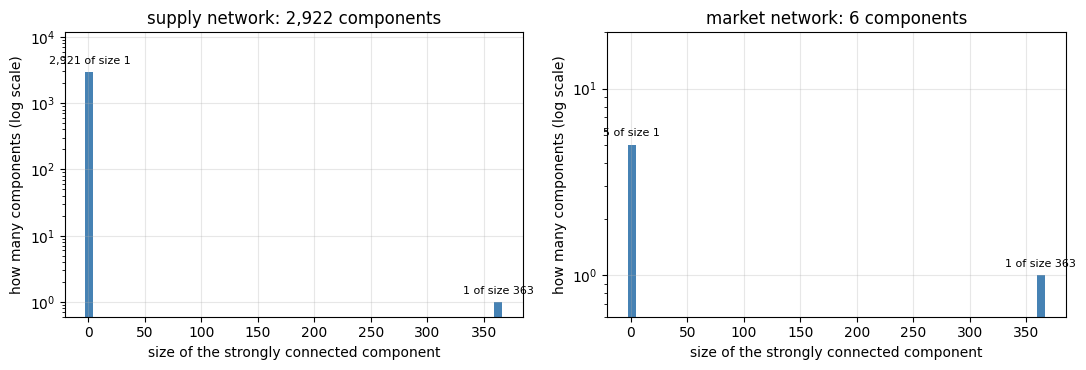

In [9]:
import matplotlib.pyplot as plt
from collections import Counter

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

for a, g, label in [(ax[0], GS, "supply network"), (ax[1], G, "market network")]:
    sizes = g.connected_components(mode="strong").sizes()
    counts = Counter(sizes)
    a.bar(list(counts.keys()), list(counts.values()), width=7, color="steelblue")
    a.set_yscale("log")
    a.set_ylim(0.6, max(counts.values()) * 4)
    for size, how_many in counts.items():
        a.annotate(f"{how_many:,} of size {size}", xy=(size, how_many),
                   xytext=(0, 6), textcoords="offset points",
                   ha="center", fontsize=8)
    a.set_xlabel("size of the strongly connected component")
    a.set_ylabel("how many components (log scale)")
    a.set_title(f"{label}: {len(sizes):,} components")
    a.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/component_sizes.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Degree distributions

Where the brief asks us to *"find the maximum and average node degrees, characterize and plot the
degree distribution"*.

We have four quantities to look at, because two independent choices give four combinations:

|  | counts edges | sums weights (people) |
|---|---|---|
| **arriving** | in-degree | in-strength |
| **leaving** | out-degree | out-strength |

The interesting column is `max / mean`: how many times bigger the most extreme university is than
the average one. It tells us how unequal each quantity is.

In [10]:
import numpy as np
from scipy import stats   # numpy handles lists of numbers efficiently

rows = []
for name, values in [
    ("in-degree",    G.degree(mode="in")),
    ("out-degree",   G.degree(mode="out")),
    ("in-strength",  G.strength(mode="in",  weights="total")),
    ("out-strength", G.strength(mode="out", weights="total")),
]:
    v = np.array(values, dtype=float)     # turn the plain list into a numpy array
    rows.append({
        "quantity": name,
        "mean": v.mean(),
        "max": v.max(),
        "max / mean": v.max() / v.mean(),
    })

degstats = pd.DataFrame(rows).set_index("quantity")
print(degstats.to_string(float_format=lambda x: f"{x:.1f}"))

              mean    max  max / mean
quantity                             
in-degree    100.2  208.0         2.1
out-degree   100.2  304.0         3.0
in-strength  576.8 2392.0         4.1
out-strength 576.8 7615.0        13.2


### Plotting it

We plot the CCDF, `P(K >= k)`, rather than a histogram. The tail of a histogram is dominated
by values that occur once or twice, which is pure noise exactly where the interesting universities
are; a cumulative quantity stays smooth all the way out.

Both axes are logarithmic. On log-log axes a straight line means a power law, the property
usually called "scale-free". We will test that claim properly in Section 8 instead of trusting the
look of the plot.

Three curves, and they behave very differently:

- the supply network's out-degree: how many places each institution sends PhDs to
- the market network's in- and out-degree: bounded, as we just discussed
- the market network's strengths: where the inequality actually shows up

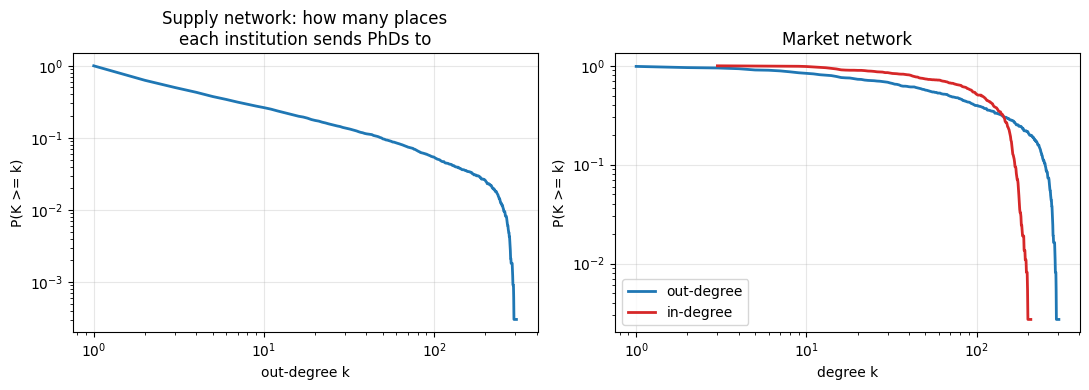

In [11]:
import matplotlib.pyplot as plt
from collections import Counter


def ccdf(values):
    """For each k, what fraction of the values are >= k. Returns (k_axis, ccdf)."""
    counts = Counter(int(v) for v in values)         # how many nodes have each exact value
    ks = np.arange(min(counts), max(counts) + 1)     # every k from the smallest to the largest
    pk = np.array([counts.get(int(k), 0) for k in ks]) / len(values)   # fraction with exactly k
    return ks, pk[::-1].cumsum()[::-1]               # add up from the right = "k or more"


fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# left panel: the supply network
ks, cc = ccdf(GS.degree(mode="out"))
keep = ks > 0
ax[0].loglog(ks[keep], cc[keep], lw=2, color="tab:blue")
ax[0].set_xlabel("out-degree k")
ax[0].set_ylabel("P(K >= k)")
ax[0].set_title("Supply network: how many places\neach institution sends PhDs to")
ax[0].grid(alpha=0.3)

# right panel: the market network, in and out
for values, label, colour in [(G.degree(mode="out"), "out-degree", "tab:blue"),
                              (G.degree(mode="in"), "in-degree", "tab:red")]:
    ks, cc = ccdf(values)
    keep = ks > 0
    ax[1].loglog(ks[keep], cc[keep], lw=2, color=colour, label=label)
ax[1].set_xlabel("degree k")
ax[1].set_ylabel("P(K >= k)")
ax[1].set_title("Market network")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/degree_ccdf.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Is any of this a power law?

A power law says the fraction of universities above `k` is cut by the same factor every time `k`
doubles, all the way into the tail. It is a strong claim, and it is testable. We follow
Clauset, Shalizi & Newman (2009), the standard procedure:

1. fit the best possible power law by maximum likelihood,
2. measure the gap between data and fit with the Kolmogorov-Smirnov distance `D`,
3. reject if that gap is bigger than random wobble could explain.

Fitting the best line first is what makes a rejection meaningful: if the best line fails, no line
works.

### First, a guard: is a power law even a candidate?

A power law has no typical value: the spread has to be at least as large as the mean. The standard
measure of that is the coefficient of variation, `CV = standard deviation / mean`. A power law
needs `CV` of order 1 or more. If a quantity is tightly clustered around its mean, fitting a power
law to it is meaningless whatever the fit returns.

In [12]:
quantities = [
    ("supply out-degree",   GS.degree(mode="out")),
    ("market out-degree",   G.degree(mode="out")),
    ("market in-degree",    G.degree(mode="in")),
    ("market out-strength", G.strength(mode="out", weights="total")),
    ("market in-strength",  G.strength(mode="in",  weights="total")),
]

rows = []
for name, values in quantities:
    v = np.array(values, dtype=float)
    rows.append({
        "quantity": name,
        "mean": v.mean(),
        "std dev": v.std(),
        "CV": v.std() / v.mean(),
    })

print(pd.DataFrame(rows).set_index("quantity").to_string(float_format=lambda x: f"{x:.2f}"))

                      mean  std dev   CV
quantity                                
supply out-degree    18.75    46.13 2.46
market out-degree   100.19    92.36 0.92
market in-degree    100.19    54.96 0.55
market out-strength 576.81  1120.28 1.94
market in-strength  576.81   558.07 0.97


### The fit (implemented from scratch)

There is no `powerlaw` package in this environment, so this section is written by hand. It is one of
the parts the brief asks us to declare as our own work rather than a library call.

Three functions, and what each is for:

| function | what it does |
|---|---|
| `powerlaw_exponent(x, xmin)` | finds the exponent `alpha` that best explains the data above `xmin` |
| `ks_distance(x, xmin, alpha)` | measures the gap `D` between the real data and that fitted curve |
| `fit_powerlaw(x)` | tries every possible `xmin` and keeps the one with the smallest gap |

Two details worth knowing:

- **`xmin`.** A power law is only ever claimed for the tail. Small universities follow different
  rules, so we let the procedure choose where the tail begins rather than assuming it starts at 1.
- **a minimum tail of 100 observations.** With a tail of only a few dozen points the test has no
  power to reject anything, and the optimiser happily returns absurd exponents. We refuse to fit
  such short tails rather than report a meaningless "pass".

In [13]:
from scipy.special import zeta   # the Hurwitz zeta function, needed by the formula


def powerlaw_exponent(x, xmin):
    """The exponent alpha that makes the observed tail most likely (maximum likelihood)."""
    x = np.asarray(x, dtype=float)
    x = x[x >= xmin]
    n, logsum = len(x), np.log(x).sum()

    def badness(a):
        # how POORLY exponent a explains the data (negative log-likelihood); smaller = better fit
        return n * np.log(zeta(a, xmin)) + a * logsum

    # there is no formula for the best alpha, so we search for it numerically:
    # repeatedly shrink the interval [lo, hi] towards wherever badness() is smallest
    lo, hi = 1.01, 12.0
    for _ in range(80):
        m1, m2 = lo + (hi - lo) / 3, hi - (hi - lo) / 3
        if badness(m1) < badness(m2):
            hi = m2
        else:
            lo = m1
    return (lo + hi) / 2, n


def ks_distance(x, xmin, alpha):
    """The biggest gap between the real cumulative curve and the fitted one. This is D.

    Both curves are staircases on the same integers, so we compare like with like:
    the observed P(X <= u) against the fitted P(X <= u), at each DISTINCT value u
    (so that tied observations are counted once, not one by one).
    """
    x = np.asarray(x, dtype=float)
    x = x[x >= xmin]
    n = len(x)
    u, counts = np.unique(x, return_counts=True)          # distinct values + how many of each
    empirical = np.cumsum(counts) / n                     # observed P(X <= u)
    fitted = 1 - zeta(alpha, u + 1) / zeta(alpha, xmin)   # fitted   P(X <= u)
    return float(np.max(np.abs(empirical - fitted)))


def fit_powerlaw(x, min_tail=100):
    """Try every possible starting point xmin; keep the one whose fit has the smallest gap D."""
    x = np.asarray(x)
    x = x[x > 0]
    best = None
    for xmin in np.unique(x):
        if (x >= xmin).sum() < min_tail:
            break                      # tail too short to test: stop here
        alpha, n = powerlaw_exponent(x, xmin)
        d = ks_distance(x, xmin, alpha)
        if best is None or d < best[2]:
            best = (int(xmin), float(alpha), d, int(n))
    return best


rows = []
for name, values in [("supply out-degree", GS.degree(mode="out")),
                     ("market out-strength", G.strength(mode="out", weights="total")),
                     ("market in-strength", G.strength(mode="in", weights="total"))]:
    xmin, alpha, D, n_tail = fit_powerlaw(values)
    d_crit = 1.36 / np.sqrt(n_tail)          # the 5% threshold for a KS test of this size
    rows.append({"quantity": name, "xmin": xmin, "alpha": alpha, "tail size": n_tail,
                 "D": D, "D_crit": d_crit,
                 "verdict": "consistent" if D < d_crit else "REJECTED"})

powerlaw_fits = {r["quantity"]: r for r in rows}   # kept for the summary at the end

print(pd.DataFrame(rows).set_index("quantity").to_string(float_format=lambda x: f"{x:.3f}"))

                     xmin  alpha  tail size     D  D_crit     verdict
quantity                                                             
supply out-degree       1  1.526       3279 0.040   0.024    REJECTED
market out-strength    56  1.519        233 0.102   0.089    REJECTED
market in-strength    867  3.634        106 0.127   0.132  consistent


### Validating our implementation against the reference package

Writing a statistical procedure by hand is only worth anything if we check it. We install the
reference `powerlaw` package and run it on the same data: if it agrees with us, our code is right;
if it disagrees, one of us has a bug and we need to know which.

This check earned its keep. An earlier version of `ks_distance` compared the fitted curve against
both edges of the empirical staircase, which is correct for a continuous distribution but
wrong for a discrete one. It inflated `D` by roughly the probability sitting exactly at `xmin`, and
pushed the `xmin` search towards spuriously high thresholds. The version above is the corrected one.

What survives the correction:

- given the same `xmin`, our `alpha` agrees with the package to four decimal places, so the
  maximum-likelihood estimator itself is correct;
- `D` agrees exactly for the supply out-degree and to within 0.003 for the out-strength;
- what still differs is only where each implementation decides the tail begins, and only for the
  in-strength, whose tail is 106 points long. There the two disagree on the verdict as well, so we
  report that case as inconclusive rather than quote whichever answer we prefer.

Note the distinction the second table below draws out: a fitting procedure has two separate parts:
the estimator (given a starting point, what exponent?) and the selection (where does the tail
start?). Ours matches the reference on the first and diverges on the second only where the data is
too thin to decide. Lumping them together would have hidden that.

In [14]:
import powerlaw   # the reference implementation of Clauset, Shalizi & Newman

rows = []
for name, values in [("supply out-degree", GS.degree(mode="out")),
                     ("market out-strength", G.strength(mode="out", weights="total")),
                     ("market in-strength", G.strength(mode="in", weights="total"))]:
    v = np.array([x for x in values if x > 0], dtype=float)

    xmin_ours, alpha_ours, D_ours, n_ours = fit_powerlaw(v)
    ref = powerlaw.Fit(v, discrete=True, estimate_discrete=False, verbose=False)

    rows.append({
        "quantity": name,
        "our xmin": xmin_ours, "ref xmin": int(ref.xmin),
        "our alpha": alpha_ours, "ref alpha": ref.alpha,
        "our D": D_ours, "ref D": ref.D,
    })

check = pd.DataFrame(rows).set_index("quantity")
print("--- what each implementation picks on its own ---")
print(check.to_string(float_format=lambda x: f"{x:.4f}"))

# The comparison above mixes two things: the ESTIMATOR (given xmin, what alpha?) and the
# SELECTION (which xmin?). To test the estimator alone, force both to the same xmin.
print("\n--- the estimator alone: both forced to the reference's xmin ---")
rows2 = []
for name, values in [("supply out-degree", GS.degree(mode="out")),
                     ("market out-strength", G.strength(mode="out", weights="total")),
                     ("market in-strength", G.strength(mode="in", weights="total"))]:
    v = np.array([x for x in values if x > 0], dtype=float)
    xmin = int(powerlaw.Fit(v, discrete=True, estimate_discrete=False, verbose=False).xmin)
    alpha_ours, _ = powerlaw_exponent(v, xmin)
    ref = powerlaw.Fit(v, discrete=True, xmin=xmin, estimate_discrete=False,
                       verbose=False).power_law
    rows2.append({"quantity": name, "xmin": xmin,
                  "our alpha": alpha_ours, "ref alpha": ref.alpha,
                  "difference": abs(alpha_ours - ref.alpha)})

print(pd.DataFrame(rows2).set_index("quantity").to_string(float_format=lambda x: f"{x:.4f}"))
print("\nOur maximum-likelihood estimator agrees with the reference to 4 decimal places.")
print("What differs is only WHERE each one decides the tail begins, and only for the")
print("in-strength, whose tail is 106 points long. That case we report as inconclusive.")

--- what each implementation picks on its own ---
                     our xmin  ref xmin  our alpha  ref alpha  our D  ref D
quantity                                                                   
supply out-degree           1         1     1.5265     1.5265 0.0397 0.0397
market out-strength        56        56     1.5189     1.5189 0.1020 0.1048
market in-strength        867       677     3.6341     2.9756 0.1268 0.1494

--- the estimator alone: both forced to the reference's xmin ---


                     xmin  our alpha  ref alpha  difference
quantity                                                   
supply out-degree       1     1.5265     1.5265      0.0000
market out-strength    56     1.5189     1.5189      0.0000
market in-strength    677     2.9756     2.9756      0.0000

Our maximum-likelihood estimator agrees with the reference to 4 decimal places.
What differs is only WHERE each one decides the tail begins, and only for the
in-strength, whose tail is 106 points long. That case we report as inconclusive.


## 9. Centrality: which universities are important, and in what sense?

The brief asks us to *"use centrality measures to find the most important vertices of the network,
and try to explain in which sense each of them is important"*.

The second half of that sentence is the interesting part. "Important" is not one thing, and on this
network the different measures give visibly different answers. Before introducing any new measure,
look at the two we already have: who sends the most people out, and who takes the most people in.

In [15]:
names = np.array(G.vs["name"])
s_out = np.array(G.strength(mode="out", weights="total"))
s_in = np.array(G.strength(mode="in", weights="total"))

cent = pd.DataFrame({"name": names, "placed": s_out, "hired": s_in})

print("TOP 10 BY PEOPLE PLACED (out-strength)")
print(cent.nlargest(10, "placed").to_string(index=False))

print("\nTOP 10 BY PEOPLE HIRED (in-strength)")
print(cent.nlargest(10, "hired").to_string(index=False))

TOP 10 BY PEOPLE PLACED (out-strength)
                                   name  placed  hired
                            UC Berkeley  7615.0 1359.0
                                Harvard  6724.0 1409.0
                 University of Michigan  5836.0 2121.0
                               Stanford  5462.0 1144.0
        University of Wisconsin-Madison  5441.0 1882.0
University of Illinois Urbana-Champaign  4923.0 2038.0
                                    MIT  4711.0  833.0
                              UT Austin  4467.0 1942.0
                                Cornell  4203.0 1564.0
                  University of Chicago  4098.0  998.0

TOP 10 BY PEOPLE HIRED (in-strength)
                                   name  placed  hired
                             Penn State  3076.0 2392.0
                  Ohio State University  3573.0 2378.0
                  University of Florida  2349.0 2272.0
                              Texas A&M  2376.0 2270.0
                          Arizona State  14

### Prestige: PageRank on the reversed graph

Counting how many people a university places ignores where they went. Placing 300 graduates,
all of them at Harvard, Stanford and MIT, says something that placing 7,000 across the country does
not.

PageRank solves exactly this problem, and it does so with a deliberately circular definition:

> A university is prestigious if prestigious universities hire its graduates.

Mechanically, PageRank is a random walker: someone who wanders the network forever, at each step
following one outgoing edge at random. The score of a node is the share of time the walker spends
there.

That makes the direction of the edges decisive. In our graph `i -> j` means "i trained somebody that
j hired", so a walker following the arrows drifts towards whoever receives the most people,
which measures size, not standing.

**So we reverse every edge first.** Each step then means:

> *pick a professor at this university at random; where did they get their PhD? go there.*

The walk traces careers backwards, drifts upward, and accumulates where the professoriate actually
comes from. That is a prestige score computed from hiring behaviour alone. No external ranking
enters the calculation at any point.

Note what makes it work: the elite hire overwhelmingly from each other, so the walk keeps returning
to the same small group rather than dispersing.

In [16]:
# build the same graph with every edge turned around
reversed_edges = [(e.target, e.source) for e in G.es]
G_rev = igraph.Graph(n=G.vcount(), edges=reversed_edges, directed=True)
G_rev.es["total"] = G.es["total"]        # carry the weights over

prestige = np.array(G_rev.pagerank(weights="total", directed=True))
cent["prestige"] = prestige

print("TOP 10 BY PRESTIGE (PageRank on the reversed graph)")
print(cent.nlargest(10, "prestige")[["name", "prestige", "placed", "hired"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

TOP 10 BY PRESTIGE (PageRank on the reversed graph)
                  name  prestige    placed     hired
               Harvard    0.0541 6724.0000 1409.0000
           UC Berkeley    0.0481 7615.0000 1359.0000
              Stanford    0.0411 5462.0000 1144.0000
                   MIT    0.0381 4711.0000  833.0000
                  Yale    0.0276 4055.0000 1174.0000
             Princeton    0.0255 3412.0000  728.0000
University of Michigan    0.0255 5836.0000 2121.0000
 University of Chicago    0.0244 4098.0000  998.0000
              Columbia    0.0243 3960.0000 1582.0000
               Cornell    0.0205 4203.0000 1564.0000


### The other measures, and why they disagree

Three more centralities from the course, each answering a different question:

- **betweenness**: how often a university lies on the shortest path between two others. High
  betweenness means "traffic passes through me": an intermediary.
- **harmonic centrality**: how easily a university is reached from everywhere else.
- **eigenvector centrality**: a cousin of PageRank: important if connected to important nodes. We
  compute it on the undirected projection, because on this directed graph it is numerically
  degenerate (the graph is not strongly connected, so igraph warns and the values collapse).

Then we compare the rankings with Spearman correlation, which asks: *do these two measures put
the universities in the same order?* 1.0 = identical ordering, 0 = unrelated.

In [17]:
# undirected version, needed for eigenvector centrality
Gu = G.as_undirected(mode="collapse", combine_edges={"total": "sum", "men": "sum", "women": "sum"})

cent["betweenness"] = G.betweenness(directed=True)
cent["harmonic"] = G.harmonic_centrality(mode="in")
cent["eigenvector"] = Gu.eigenvector_centrality(weights="total")
cent["in_degree"] = G.degree(mode="in")
cent["out_degree"] = G.degree(mode="out")

for measure in ["betweenness", "harmonic"]:
    print(f"TOP 8 BY {measure.upper()}")
    print(cent.nlargest(8, measure)[["name", measure, "placed", "hired"]]
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    print()

TOP 8 BY BETWEENNESS
                 name  betweenness   placed    hired
   University of Utah     1808.134 1068.000 1342.000
            Texas A&M     1792.697 2376.000 2270.000
       Michigan State     1730.897 2841.000 2059.000
           Vanderbilt     1499.896 1156.000 1337.000
    Boston University     1474.053  983.000 1463.000
Ohio State University     1434.738 3573.000 2378.000
           Penn State     1376.423 3076.000 2392.000
University of Florida     1357.498 2349.000 2272.000

TOP 8 BY HARMONIC
                       name  harmonic   placed    hired
                  Texas A&M     0.771 2376.000 2270.000
              East Carolina     0.759   56.000 1084.000
      University of Florida     0.756 2349.000 2272.000
                 Penn State     0.752 3076.000 2392.000
University of South Florida     0.750  534.000 1272.000
     University of Kentucky     0.746  988.000 1720.000
      Ohio State University     0.745 3573.000 2378.000
              Arizona State     0.7

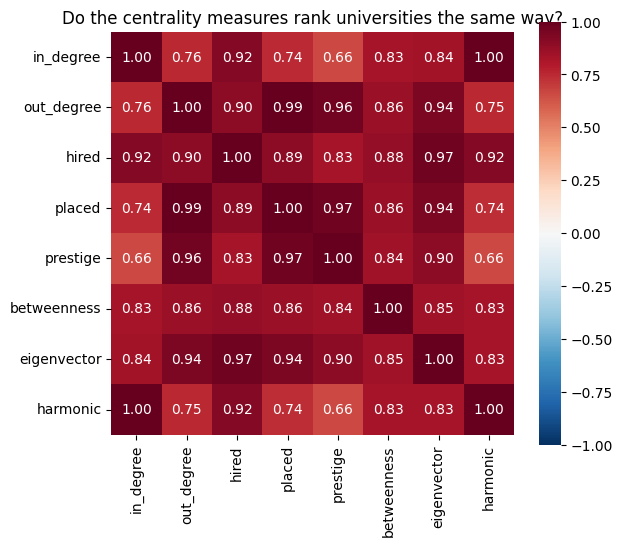

prestige vs placed   : 0.974
prestige vs hired    : 0.833
prestige vs in_degree: 0.664
in_degree vs harmonic: 0.999


In [18]:
import seaborn as sns

measures = ["in_degree", "out_degree", "hired", "placed",
            "prestige", "betweenness", "eigenvector", "harmonic"]
rho = cent[measures].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(rho, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Do the centrality measures rank universities the same way?")
plt.savefig("figures/centrality_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"prestige vs placed   : {rho.loc['prestige', 'placed']:.3f}")
print(f"prestige vs hired    : {rho.loc['prestige', 'hired']:.3f}")
print(f"prestige vs in_degree: {rho.loc['prestige', 'in_degree']:.3f}")
print(f"in_degree vs harmonic: {rho.loc['in_degree', 'harmonic']:.3f}")

## 10. Transitivity

The brief asks us to *"measure the level of transitivity of the network"*.

Clustering asks: if A and B both exchange faculty with C, do A and B also exchange with each other?
A closed triangle. It measures how far the network clumps into tight groups.

There are two ways to average this over a whole network, and they are not the same number:

- **global clustering `C`**: pool every connected triple in the graph and ask what fraction close
  into triangles. High-degree universities sit at the centre of enormous numbers of triples, so
  they dominate the result.
- **average local clustering**: compute the fraction separately inside each university's own
  neighbourhood, then average those. Every university gets one vote, regardless of size.

Reporting only one of the two quietly hides a choice, so we report both.

Clustering is defined on undirected graphs, so we use the collapsed projection `Gu`.

In [19]:
C_global = Gu.transitivity_undirected()
C_local = np.array(Gu.transitivity_local_undirected(mode="zero"))
C_avg = Gu.transitivity_avglocal_undirected(mode="zero")

print(f"market network   global C      = {C_global:.4f}")
print(f"market network   average C_i   = {C_avg:.4f}")

GSu = GS.as_undirected(mode="collapse")
print(f"supply network   global C      = {GSu.transitivity_undirected():.4f}")

# For reference: a purely random graph of the same density would have C roughly equal
# to the density itself, because any two neighbours close a triangle at exactly that rate.
print(f"\nmarket density (the 'random' baseline) = {G.ecount() / (G.vcount() * (G.vcount() - 1)):.4f}")

market network   global C      = 0.6833
market network   average C_i   = 0.7547
supply network   global C      = 0.4048

market density (the 'random' baseline) = 0.2730


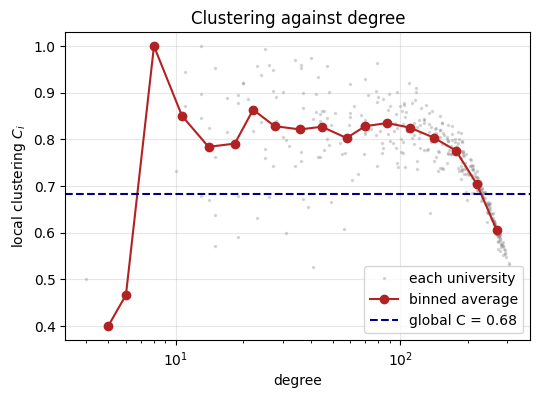

In [20]:
# does clustering depend on how connected a university is?
degrees = np.array(Gu.degree())
d = pd.DataFrame({"degree": degrees, "C_i": C_local})
d = d[d.degree > 1]

bins = np.logspace(np.log10(d.degree.min()), np.log10(d.degree.max() + 1), 20)
d["bin"] = pd.cut(d.degree, bins=bins)
binned = d.groupby("bin", observed=True).agg(degree=("degree", "mean"), C_i=("C_i", "mean")).dropna()

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(d.degree, d.C_i, ".", ms=3, alpha=0.25, color="gray", label="each university")
ax.semilogx(binned.degree, binned.C_i, "o-", color="firebrick", label="binned average")
ax.axhline(C_global, ls="--", color="navy", label=f"global C = {C_global:.2f}")
ax.set_xlabel("degree")
ax.set_ylabel("local clustering $C_i$")
ax.set_title("Clustering against degree")
ax.legend()
ax.grid(alpha=0.3)
plt.savefig("figures/clustering.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Community structure

The brief asks us to *"partition the network in communities and characterize the community
structure and their intra- and inter-connection patterns"*.

A community is a group of nodes more densely connected among themselves than with the rest of
the network. Here that means a set of universities that mostly hire from each other.

We run two algorithms from Lecture 7:

- **Louvain** (`community_multilevel`), which maximises modularity;
- **walktrap**, which is based on random walks, as an independent check.

Modularity `Q` measures how much more internal connection a partition has than would be
expected by chance. Values above roughly 0.3 are normally taken as evidence of real community
structure.

We have a prediction before we start: communities need absent edges to exist, because a community
boundary is a place where connections stop. At density 0.27 there are not many absences to hide a
boundary in, so `Q` should come out low.

In [21]:
import random
random.seed(42)      # Louvain is randomised; fix the seed so the notebook is reproducible

weights = [e["total"] for e in Gu.es]

louvain = Gu.community_multilevel(weights=weights)
walktrap = Gu.community_walktrap(weights=weights).as_clustering()

Q_louvain = Gu.modularity(louvain, weights=weights)
Q_walktrap = Gu.modularity(walktrap, weights=weights)

print(f"Louvain : {len(louvain):3d} communities,  Q = {Q_louvain:.4f}")
print(f"          sizes: {sorted(louvain.sizes(), reverse=True)}")
print(f"walktrap: {len(walktrap):3d} communities,  Q = {Q_walktrap:.4f}")
print(f"          sizes: {sorted(walktrap.sizes(), reverse=True)[:8]}")

Louvain :   5 communities,  Q = 0.1501
          sizes: [128, 105, 68, 62, 5]
walktrap:   9 communities,  Q = 0.1301
          sizes: [196, 160, 5, 2, 1, 1, 1, 1]


In [22]:
# who is in each community? list the biggest placers of each
membership = np.array(louvain.membership)
order = np.argsort(-np.array(louvain.sizes()))     # biggest community first

for rank, c in enumerate(order):
    members = np.where(membership == c)[0]
    leaders = members[np.argsort(-s_out[members])][:6]
    print(f"community {rank}  (n = {len(members)})")
    print("   ", ", ".join(names[leaders]))
    print()

community 0  (n = 128)
    Harvard, University of Michigan, MIT, Cornell, University of Chicago, Yale

community 1  (n = 105)
    UT Austin, UNC, Texas A&M, University of Florida, University of Georgia, Florida State

community 2  (n = 68)
    University of Wisconsin-Madison, University of Illinois Urbana-Champaign, University of Minnesota Twin Cities, Ohio State University, Purdue, Penn State

community 3  (n = 62)
    UC Berkeley, Stanford, UCLA, UW, University of Arizona, UC San Diego

community 4  (n = 5)
    Southwestern Baptist Theological Seminary, Southeastern Baptist Theological Seminary, New Orleans Baptist Theological Seminary, Dallas Theological Seminary, Mid-America Baptist Theological Seminary



### Flows between communities (built by hand)

The brief also asks for the intra- and inter-connection patterns. So we count, for every pair of
communities, how many people moved from one to the other.

That table is exactly the matrix `L_IJ` of the degree-corrected stochastic block model from
Lecture 7, measured from the data rather than fitted.

We show it twice, because the two versions answer different questions:

- **absolute counts**: where is the volume?
- **row-normalised**: of everything community I produced, what share went to each community? This
  is the more informative one, because it removes the effect of community size.

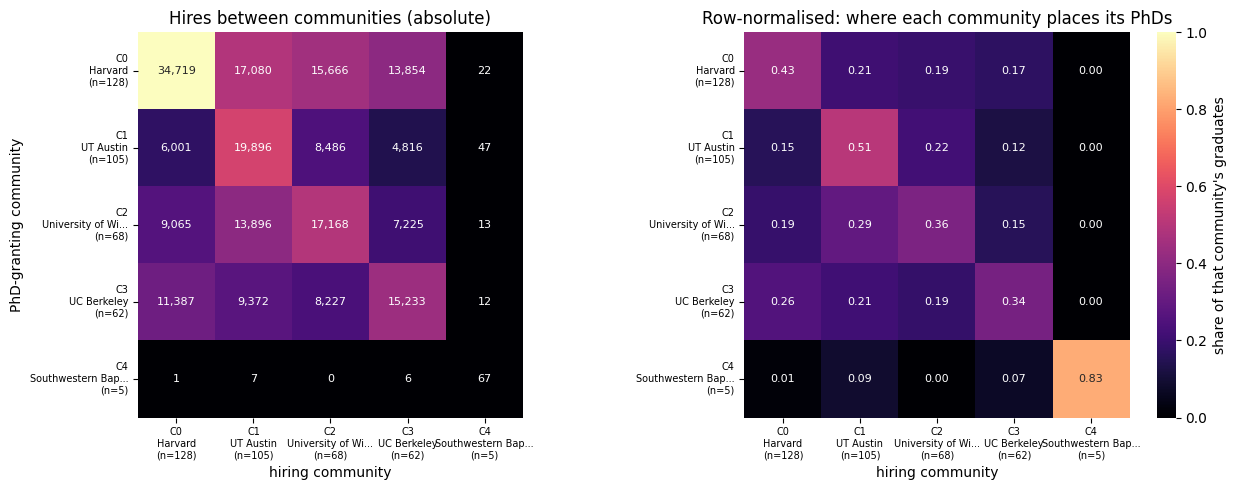

share of all hiring flow that stays inside a community: 41.0%
expected if flows ignored communities, given their sizes: 25.5%
(1/K would give 20%, but that assumes equally sized communities)


In [23]:
K = len(order)
position = {c: i for i, c in enumerate(order)}      # community id -> row/column in the matrix

B = np.zeros((K, K))
for e in G.es:                                       # directed graph: direction matters here
    B[position[membership[e.source]], position[membership[e.target]]] += e["total"]

labels = []
for rank, c in enumerate(order):
    members = np.where(membership == c)[0]
    lead = names[members[np.argmax(s_out[members])]]
    lead = lead[:16] + "..." if len(lead) > 19 else lead
    labels.append(f"C{rank}\n{lead}\n(n={len(members)})")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(B, cmap="magma", ax=ax[0], square=True, annot=True, fmt=",.0f",
            annot_kws={"size": 8}, xticklabels=labels, yticklabels=labels, cbar=False)
ax[0].set_xlabel("hiring community"); ax[0].set_ylabel("PhD-granting community")
ax[0].set_title("Hires between communities (absolute)")

sns.heatmap(B / B.sum(axis=1, keepdims=True), cmap="magma", ax=ax[1], square=True, annot=True,
            fmt=".2f", annot_kws={"size": 8}, xticklabels=labels, yticklabels=labels,
            vmin=0, vmax=1, cbar_kws={"label": "share of that community's graduates"})
ax[1].set_xlabel("hiring community"); ax[1].set_ylabel("")
ax[1].set_title("Row-normalised: where each community places its PhDs")

for a in ax:
    a.tick_params(axis="x", rotation=0, labelsize=7)
    a.tick_params(axis="y", rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig("figures/community_flows.png", dpi=300, bbox_inches="tight")
plt.show()

inside = np.trace(B) / B.sum()

# The baseline is not 1/K. That would assume the communities are all the same size, and ours
# range from 128 universities down to 5. If flows ignored communities, the chance that both ends
# of a hire land in the same community is the sum over communities of
#   (that community's share of outgoing people) x (its share of incoming people).
out_share = np.array([s_out[membership == c].sum() for c in order]) / s_out.sum()
in_share = np.array([s_in[membership == c].sum() for c in order]) / s_in.sum()
baseline = float((out_share * in_share).sum())

print(f"share of all hiring flow that stays inside a community: {100 * inside:.1f}%")
print(f"expected if flows ignored communities, given their sizes: {100 * baseline:.1f}%")
print(f"(1/K would give {100 / K:.0f}%, but that assumes equally sized communities)")

## 12. Assortativity

The brief asks us to *"compute the degree assortativity of the network and, if the vertices have
scalar attributes, compute the assortativity with respect to those attributes"*.

Assortativity asks whether similar nodes connect to each other. It is a correlation
coefficient, so it runs from -1 to +1:

- **positive**: the well-connected attach to the well-connected. Social networks look like this.
- **negative**: the well-connected attach to the poorly-connected. Most technological and
  biological networks look like this.

We can predict the sign here from arithmetic alone. There are a handful of large universities and
hundreds of small ones. A university that places graduates almost everywhere is therefore forced
to send most of them to small institutions, simply because most institutions are small. That is
negative assortativity by construction.

The dataset also gives us a scalar node attribute: `non_attrition`, the number of faculty who
stayed, a proxy for the size of an institution's faculty. So we can answer the second half of the
brief's question too, which many datasets do not allow.

In [24]:
r_directed = G.assortativity_degree(directed=True)
r_undirected = Gu.assortativity_degree(directed=False)

faculty_size = np.array(G.vs["non_attrition"], dtype=float)
left = np.array(G.vs["attrition"], dtype=float)

r_size = Gu.assortativity(list(faculty_size), directed=False)
r_left = Gu.assortativity(list(left), directed=False)

print(f"degree assortativity, directed    = {r_directed:+.4f}")
print(f"degree assortativity, undirected  = {r_undirected:+.4f}")
print(f"assortativity by faculty size     = {r_size:+.4f}")
print(f"assortativity by faculty who left = {r_left:+.4f}")
print(f"\nsupply network, degree            = {GS.assortativity_degree(directed=True):+.4f}")

degree assortativity, directed    = -0.1409
degree assortativity, undirected  = -0.1967
assortativity by faculty size     = -0.0910
assortativity by faculty who left = -0.0941

supply network, degree            = -0.2118


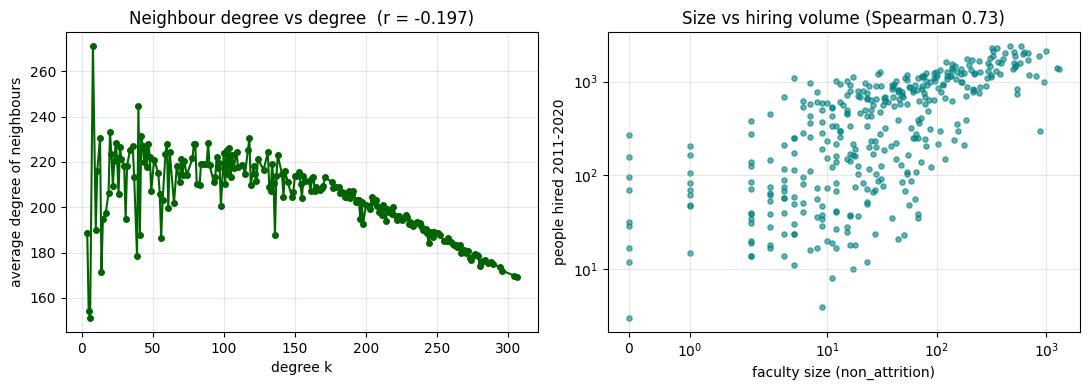

In [25]:
# knn(k): for universities of degree k, what is the average degree of their neighbours?
# A downward slope is the visual signature of disassortativity.
knn_per_node, knn_by_degree = Gu.knn()
knn_by_degree = np.array(knn_by_degree, dtype=float)
k_axis = np.arange(1, len(knn_by_degree) + 1)
valid = ~np.isnan(knn_by_degree)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(k_axis[valid], knn_by_degree[valid], "o-", ms=4, color="darkgreen")
ax[0].set_xlabel("degree k")
ax[0].set_ylabel("average degree of neighbours")
ax[0].set_title(f"Neighbour degree vs degree  (r = {r_undirected:+.3f})")
ax[0].grid(alpha=0.3)

ax[1].scatter(faculty_size, s_in, s=14, alpha=0.6, color="teal")
ax[1].set_xscale("symlog"); ax[1].set_yscale("symlog")
ax[1].set_xlabel("faculty size (non_attrition)")
ax[1].set_ylabel("people hired 2011-2020")
ax[1].set_title(f"Size vs hiring volume "
                f"(Spearman {stats.spearmanr(faculty_size, s_in).statistic:.2f})")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/assortativity.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Null models: what is actually surprising here?

Several numbers so far look dramatic on their own, such as clustering of 0.68, assortativity of -0.14,
but we have no way to judge them without knowing what randomness alone would produce.

A null model is a random graph that keeps some features of the real network and scrambles
everything else. What you choose to keep defines the question:

| model | keeps | asks |
|---|---|---|
| **Erdős-Rényi** | number of nodes and edges | how much of this is just **density**? |
| **configuration model** | every node's exact in- and out-degree | how much is just the **degree sequence**? |

The configuration model is the stricter test: it already grants that Berkeley is huge and East
Carolina is small, so anything it still cannot reproduce is not explained by size.

**Implementation note.** The configuration model is generated allowing multi-edges and self-loops,
and then simplified. At this density collisions are frequent, so it ends up with fewer edges than
the real network. That makes the comparison slightly conservative, since the null model is a little
sparser, and we prefer that to rejection sampling, which biases the ensemble by discarding draws.

In [26]:
np.random.seed(42)
random.seed(42)

N, E = G.vcount(), G.ecount()

ER = igraph.Graph.Erdos_Renyi(n=N, m=E, directed=True)

CM = igraph.Graph.Degree_Sequence(list(G.degree(mode="out")),
                                  list(G.degree(mode="in")),
                                  method="configuration")
CM = CM.simplify(multiple=True, loops=True)


def describe(g, label):
    scc = g.connected_components(mode="strong")
    gu = g.as_undirected(mode="collapse")
    return {
        "model": label,
        "edges": g.ecount(),
        "reciprocity": g.reciprocity(),
        "largest SCC": max(scc.sizes()),
        "clustering C": gu.transitivity_undirected(),
        "assortativity": g.assortativity_degree(directed=True),
        "modularity Q": gu.modularity(gu.community_multilevel()),
    }


comparison = pd.DataFrame([
    describe(G, "empirical"),
    describe(ER, "Erdos-Renyi"),
    describe(CM, "configuration"),
]).set_index("model")

print(comparison.to_string(float_format=lambda x: f"{x:.4f}"))

               edges  reciprocity  largest SCC  clustering C  assortativity  modularity Q
model                                                                                    
empirical      36870       0.5301          363        0.6833        -0.1409        0.0651
Erdos-Renyi    36870       0.2810          368        0.4695        -0.0096        0.0430
configuration  27611       0.3329          363        0.5477        -0.0452        0.0460


## 14. Where the hierarchy actually lives

Sections 6 and 13 established what the hierarchy is not. The topology is dense (0.27), almost
entirely mutually connected (363 of 368 in one strongly connected component), and the null models
reproduce most of it. On the question of who is connected to whom, this market is close to
complete and close to random.

So we look at the weights instead.

Net flow is the trade balance of an institution: people it produced minus people it hired.

    net flow = out-strength - in-strength

If the market were flat, this would scatter around zero.

In [27]:
cent["net_flow"] = cent["placed"] - cent["hired"]

print("BIGGEST NET EXPORTERS")
print(cent.nlargest(6, "net_flow")[["name", "placed", "hired", "net_flow"]]
      .to_string(index=False))

print("\nBIGGEST NET IMPORTERS")
print(cent.nsmallest(6, "net_flow")[["name", "placed", "hired", "net_flow"]]
      .to_string(index=False))

# does position in the hierarchy predict the trade balance?
# restrict to institutions active on both sides, so the ratio is meaningful
active = cent[(cent["hired"] >= 50) & (cent["placed"] >= 50)].copy()
rho = stats.spearmanr(active["prestige"], active["net_flow"])
print(f"\ninstitutions with at least 50 hires and 50 placements: {len(active)}")
print(f"Spearman(prestige, net flow) = {rho.statistic:+.3f}   (p = {rho.pvalue:.1e})")

BIGGEST NET EXPORTERS
                           name  placed  hired  net_flow
                    UC Berkeley  7615.0 1359.0    6256.0
                        Harvard  6724.0 1409.0    5315.0
                       Stanford  5462.0 1144.0    4318.0
                            MIT  4711.0  833.0    3878.0
         University of Michigan  5836.0 2121.0    3715.0
University of Wisconsin-Madison  5441.0 1882.0    3559.0

BIGGEST NET IMPORTERS
           name  placed  hired  net_flow
   George Mason   235.0 1331.0   -1096.0
  Brigham Young   132.0 1198.0   -1066.0
  East Carolina    56.0 1084.0   -1028.0
    Texas State    37.0 1017.0    -980.0
San Diego State    41.0  920.0    -879.0
          IUPUI   101.0  974.0    -873.0

institutions with at least 50 hires and 50 placements: 233
Spearman(prestige, net flow) = +0.537   (p = 7.7e-19)


### The direction of every hire

Net flow is a raw count, so it carries institution size inside it: a small but very prestigious
place can only ever have a modest net flow. That is why the correlation with prestige is +0.54
rather than something higher.

So we ask a question that does not depend on size at all, and can be put to every single edge:

> does this hire move down the prestige ranking, or up?

Each of the 238,986 hires either goes from a more prestigious institution to a less prestigious
one, or the other way. Under a flat market it would be roughly 50/50.

In [28]:
down = 0
up = 0
for e in G.es:
    if prestige[e.target] < prestige[e.source]:
        down += e["total"]        # the hiring institution is less prestigious: downhill
    else:
        up += e["total"]

print(f"hires moving DOWN the prestige ranking: {down:,}  ({100 * down / (down + up):.1f}%)")
print(f"hires moving UP   the prestige ranking: {up:,}   ({100 * up / (down + up):.1f}%)")

down_all, up_all = down, up   # kept for the summary at the end
print(f"\na flat market would give roughly 50% / 50%")

hires moving DOWN the prestige ranking: 166,076  (78.2%)
hires moving UP   the prestige ranking: 46,190   (21.8%)

a flat market would give roughly 50% / 50%


### Self-hiring, and who does it

During preprocessing we set the self-loops aside: 358 edges and 26,720 people, which is 11.2% of hires inside the market network and 9.7% of every hire in the dataset. Now we
ask whether academic inbreeding is spread evenly across the market.

It is not, and the direction is counter-intuitive at first. **Self-hiring correlates positively
with prestige.** The mechanism follows directly from the 78% result: hires move downhill, so a
graduate of a top institution has nowhere higher to go, and staying is the only lateral move
available. A lower-ranked institution, by contrast, can hire someone from a better place than
itself, and prefers to.

In [29]:
# how many people each institution hired from itself
self_hire_count = self_loops.set_index("source")["total"]
cent["self_hires"] = [float(self_hire_count.get(i, 0)) for i in G.vs["index"]]

# as a share of everyone it hired, self-hires included
cent["self_hire_rate"] = cent["self_hires"] / (cent["hired"] + cent["self_hires"])

active = cent[(cent["hired"] >= 50) & (cent["placed"] >= 50)].copy()
rho_self = stats.spearmanr(active["prestige"], active["self_hire_rate"])

print(f"overall self-hiring rate: {cent['self_hires'].sum() / (cent['hired'].sum() + cent['self_hires'].sum()) * 100:.1f}%")
print(f"Spearman(prestige, self-hire rate) = {rho_self.statistic:+.3f}  (p = {rho_self.pvalue:.1e})")

print("\nHIGHEST SELF-HIRING RATES (among institutions active on both sides)")
print(active.nlargest(8, "self_hire_rate")[["name", "self_hires", "hired", "self_hire_rate"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

overall self-hiring rate: 11.2%
Spearman(prestige, self-hire rate) = +0.323  (p = 4.5e-07)

HIGHEST SELF-HIRING RATES (among institutions active on both sides)
                               name  self_hires    hired  self_hire_rate
                         Loma Linda     102.000  123.000           0.453
                                MIT     401.000  833.000           0.325
                            Harvard     592.000 1409.000           0.296
UT Health Science Center at Houston     125.000  355.000           0.260
   University of Maryland Baltimore      74.000  211.000           0.260
                      Texas Woman's      84.000  254.000           0.249
                   UC San Francisco     154.000  476.000           0.244
                  Nova Southeastern      47.000  153.000           0.235


### Gender, and a caveat that is not optional

Every edge carries its count split into `men` and `women`, so we can compute, for each institution,
the share of women among the faculty it hired. Across the whole dataset the figure is about 35%.

**The result is a negative correlation with prestige.** Before reading anything into it, note what
this analysis cannot establish.

The network aggregates all 107 academic fields into one. Fields differ enormously both in their
gender composition (education and nursing are majority women; physics and engineering are heavily
men) and in which institutions dominate them (MIT and Caltech are large in engineering, negligible
in education).

If the elite institutions are concentrated in male-dominated fields and less prestigious ones in
female-dominated fields, this exact correlation appears **even if every single field hires women at
an identical rate everywhere**. That is Simpson's paradox: an association that exists in pooled
data and disappears within each group.

Our data cannot separate the two, because we deliberately restricted the project to the aggregate
network. So the defensible statement is:

> the association exists at the aggregate level, and its cause is not identified here.

Not "prestigious universities discriminate". Testing that properly would mean repeating the analysis
on the 107 per-field networks, which the same source provides, and which we name as future work.

In [30]:
women_in = np.zeros(G.vcount())
men_in = np.zeros(G.vcount())
for e in G.es:
    women_in[e.target] += e["women"]
    men_in[e.target] += e["men"]

cent["frac_women"] = np.where(women_in + men_in > 0, women_in / (women_in + men_in), np.nan)
overall = women_in.sum() / (women_in.sum() + men_in.sum())

active = cent[(cent["hired"] >= 50) & (cent["placed"] >= 50)].copy()
rho_gender = stats.spearmanr(active["prestige"], active["frac_women"], nan_policy="omit")

print(f"women as a share of hires inside the market network: {100 * overall:.1f}%")
print(f"Spearman(prestige, share of women hired) = {rho_gender.statistic:+.3f}"
      f"  (p = {rho_gender.pvalue:.1e},  n = {len(active)})")

women as a share of hires inside the market network: 34.8%
Spearman(prestige, share of women hired) = -0.286  (p = 9.0e-06,  n = 233)


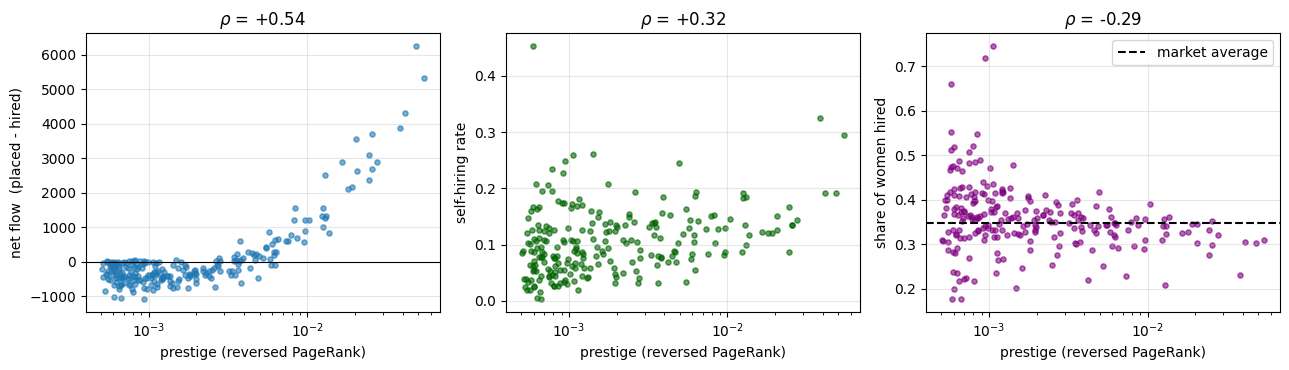

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

panels = [("net_flow", "net flow  (placed - hired)", "tab:blue", rho),
          ("self_hire_rate", "self-hiring rate", "darkgreen", rho_self),
          ("frac_women", "share of women hired", "purple", rho_gender)]

for a, (column, label, colour, correlation) in zip(ax, panels):
    a.scatter(active["prestige"], active[column], s=14, alpha=0.6, color=colour)
    a.set_xscale("log")
    a.set_xlabel("prestige (reversed PageRank)")
    a.set_ylabel(label)
    a.set_title(f"$\\rho$ = {correlation.statistic:+.2f}")
    a.grid(alpha=0.3)

ax[0].axhline(0, color="k", lw=0.8)
ax[2].axhline(overall, ls="--", color="k", label="market average")
ax[2].legend()

plt.tight_layout()
plt.savefig("figures/hierarchy_and_gender.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Drawing the network

The brief asks for "a graphical representation of the network". This sounds like the easiest
requirement on the list; on this network it is the one that needs the most thought.

The standard approach is a force-directed layout: treat edges as springs pulling connected
nodes together and let the arrangement settle. It works beautifully on sparse networks: clusters
separate, hubs stand out.

Let us try it here, on the 60 most prestigious institutions with the strongest 10% of their
edges.

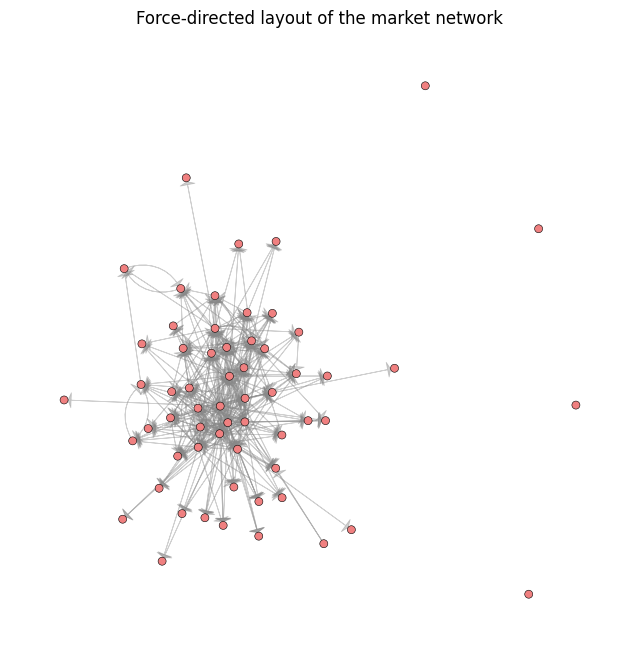

In [32]:
top60 = cent.nlargest(60, "prestige").index.tolist()
sub = G.induced_subgraph(top60)
threshold = np.percentile(sub.es["total"], 90)
sub = sub.subgraph_edges([e.index for e in sub.es if e["total"] >= threshold],
                         delete_vertices=False)

fig, ax = plt.subplots(figsize=(8, 8))
igraph.plot(sub, target=ax, layout=sub.layout("fr"),
            vertex_size=8, vertex_color="lightcoral", vertex_frame_width=0.4,
            edge_width=0.6, edge_color="#88888866", edge_arrow_size=3)
ax.set_title("Force-directed layout of the market network")
ax.axis("off")
plt.savefig("figures/hairball.png", dpi=200, bbox_inches="tight")
plt.show()

### The prestige ladder (our own design)

The hairball is not a failure of the layout algorithm. It is an accurate rendering of a network
where nearly everything connects to nearly everything. It is uninformative because the *connection
pattern* is uninformative, which is precisely what Sections 6 and 13 established.

So instead of drawing the connections, we draw what carries the information. Two choices:

- **vertical position = prestige rank.** Now every arrow is readable: pointing down means the hire
  descended the ranking, pointing up means it ascended. We colour them accordingly.
- **horizontal position = Louvain community**, so the regional structure from Section 11 appears in
  the same picture at no extra cost.

The result turns the 78% statistic into something you can see.

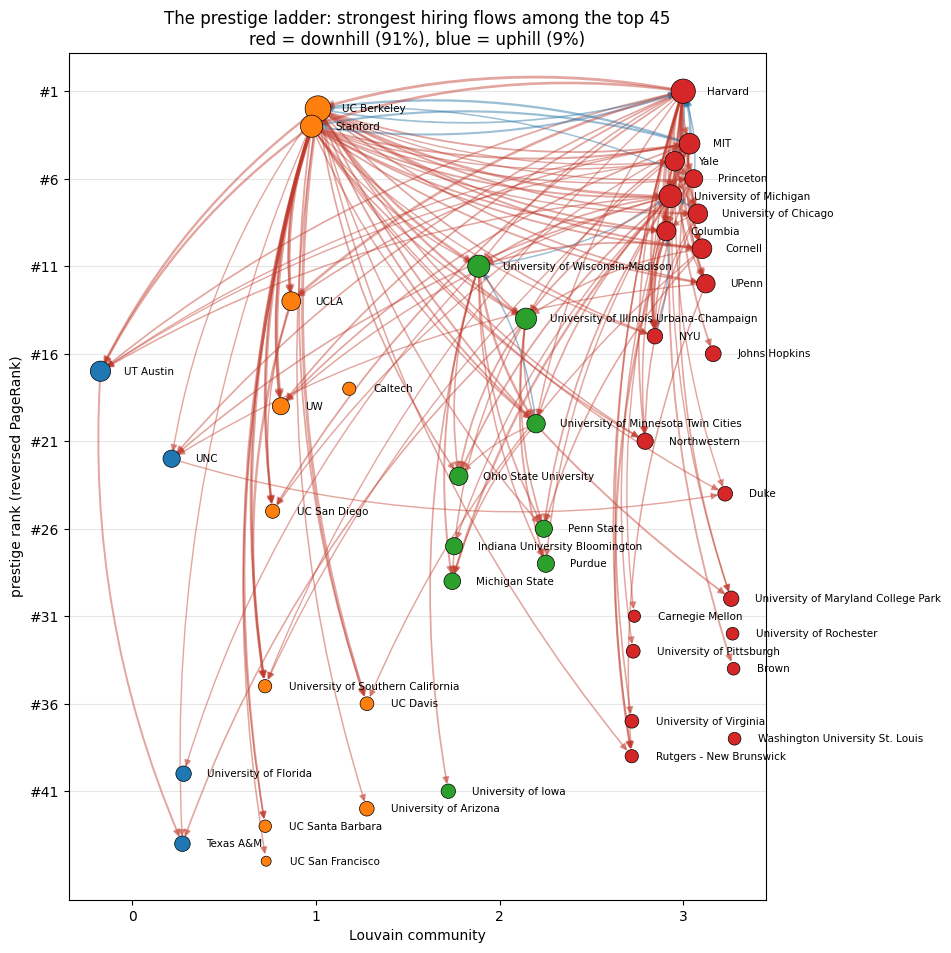

among the top 45, 91.3% of the strongest flow goes downhill


In [33]:
TOP = 45
top = cent.nlargest(TOP, "prestige").index.tolist()

rank = {v: i for i, v in enumerate(top)}                  # 0 = most prestigious
xs = {v: membership[v] + 0.28 * np.sin(3.1 * i) for i, v in enumerate(top)}   # jitter, avoid overlap
ys = {v: -i for i, v in enumerate(top)}                   # negative so rank 1 sits at the top

# keep only the strongest flows, otherwise the picture fills up again
edges_top = [(e.source, e.target, e["total"]) for e in G.es
             if e.source in rank and e.target in rank]
cut = np.percentile([w for _, _, w in edges_top], 92)
edges_top = [(s, t, w) for s, t, w in edges_top if w >= cut]

down_top = sum(w for s, t, w in edges_top if rank[t] > rank[s])
up_top = sum(w for s, t, w in edges_top if rank[t] < rank[s])

fig, ax = plt.subplots(figsize=(9, 11))
wmax = max(w for _, _, w in edges_top)

for s, t, w in sorted(edges_top, key=lambda e: e[2]):      # thin edges first, thick on top
    downhill = rank[t] > rank[s]
    ax.annotate("", xy=(xs[t], ys[t]), xytext=(xs[s], ys[s]),
                arrowprops=dict(arrowstyle="-|>", lw=0.3 + 2.2 * w / wmax,
                                color="#c0392b" if downhill else "#2471a3",
                                alpha=0.45, connectionstyle="arc3,rad=0.12",
                                shrinkA=4, shrinkB=5))

sizes = 25 + 320 * (s_out[top] / s_out[top].max())
ax.scatter([xs[v] for v in top], [ys[v] for v in top], s=sizes, zorder=3,
           c=[f"C{membership[v]}" for v in top], edgecolors="black", linewidths=0.5)
for v in top:
    ax.text(xs[v] + 0.13, ys[v], names[v], fontsize=7.5, va="center", zorder=4)

ax.set_yticks([-i for i in range(0, TOP, 5)])
ax.set_yticklabels([f"#{i + 1}" for i in range(0, TOP, 5)])
ax.set_ylabel("prestige rank (reversed PageRank)")
ax.set_xlabel("Louvain community")
ax.set_xticks(sorted(set(membership[v] for v in top)))
ax.set_title(f"The prestige ladder: strongest hiring flows among the top {TOP}\n"
             f"red = downhill ({100 * down_top / (down_top + up_top):.0f}%), "
             f"blue = uphill ({100 * up_top / (down_top + up_top):.0f}%)")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.3)

plt.savefig("figures/prestige_ladder.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"among the top {TOP}, {100 * down_top / (down_top + up_top):.1f}% of the strongest flow goes downhill")

## 16. Saving the results

Every figure quoted in the written report is read from `results.json`, which this cell writes. No
number in the paper is typed in by hand: if the analysis changes, the file changes with it and the
paper can be checked against it.

In [34]:
import json

results = {
    # data and preprocessing
    "n_nodes_total": len(nodes), "n_hirers": len(hirers),
    "n_producers": int(edges["source"].nunique()),
    "hires_total": int(edges["total"].sum()),
    "hires_internal": int(internal["total"].sum()),
    "hires_external": int(external["total"].sum()),
    "men_total": int(edges["men"].sum()), "women_total": int(edges["women"].sum()),
    "n_self_loops": len(self_loops), "self_hires": int(self_loops["total"].sum()),
    # the two graphs
    "supply_N": GS.vcount(), "supply_E": GS.ecount(),
    "market_N": G.vcount(), "market_E": G.ecount(),
    "market_density": G.ecount() / (G.vcount() * (G.vcount() - 1)),
    "market_reciprocity": G.reciprocity(),
    "market_diameter": G.diameter(),
    "market_apl": G.average_path_length(),
    # components
    "supply_n_scc": len(GS.connected_components(mode="strong")),
    "market_largest_scc": max(G.connected_components(mode="strong").sizes()),
    # distributions and the power-law test
    "powerlaw_fits": powerlaw_fits,
    # centrality
    "top_prestige": cent.nlargest(10, "prestige")[["name", "prestige"]].values.tolist(),
    # clustering, communities, assortativity
    "C_global": C_global, "C_avg_local": C_avg,
    "n_communities": len(louvain), "Q_louvain": Q_louvain,
    "community_sizes": sorted(louvain.sizes(), reverse=True),
    "intra_community_share": float(inside),
    "intra_community_baseline": baseline,
    "r_degree": G.assortativity_degree(directed=True),
    "r_faculty_size": r_size,
    # null models
    "null_models": comparison.reset_index().to_dict("records"),
    # the hierarchy
    "downhill_hires": int(down_all), "uphill_hires": int(up_all),
    "downhill_share": down_all / (down_all + up_all),
    "downhill_share_top45": down_top / (down_top + up_top),
    "rho_prestige_netflow": float(rho.statistic),
    "rho_prestige_selfhire": float(rho_self.statistic),
    "rho_prestige_women": float(rho_gender.statistic),
    "women_share_market": float(overall),
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=1, default=float)

print(f"wrote results.json with {len(results)} entries")

wrote results.json with 40 entries


---

## What the analysis found

**The topology is not hierarchical.** 363 of the 368 institutions sit in one strongly connected
component, the density is 0.273, and the null models reproduce the component structure exactly and
most of the clustering. On the question of who exchanges with whom, this market is close to complete
and close to random.

**The flow is hierarchical.** Reversing the edges and running PageRank gives a prestige score built
only from hiring behaviour, and **78.2% of the 212,266 hires between distinct institutions descend
it**. Net flow correlates with prestige at $\rho = 0.537$, and Berkeley produces 5.6 professors for
every one it hires.

Reciprocity is the clearest departure from randomness, at 0.530 against 0.281 for an
Erdos-Renyi graph of the same density.

**Two expected properties fail.** The power law is rejected wherever the tail is long enough to test
it, and the near-acyclicity of the raw data turns out to measure how the rosters were collected
rather than how academia works.

**One result is reported but not interpreted.** The share of women hired correlates negatively with
prestige, but the network merges 107 fields and the association could be produced by field
composition alone. We report it and do not claim a cause.

The written report is in `paper.pdf`. Every figure it quotes is read from `results.json`, which the
cell above writes.